# VEDB Diffusion-Length Fitting — Experimental Data

This notebook fits the **positron diffusion length** L₊ in a bulk Cu sample from a variable-energy Doppler broadening (VEDB) measurement. The input is the measured S(E) curve; the output is L₊ with a statistical uncertainty and a full χ² confidence-interval profile.

## Model

The positron transport is described by the steady-state diffusion–annihilation equation:

$$\frac{d^2 c(z)}{dz^2} - \frac{c(z)}{L_+^2} = -I(z)$$

where $c(z)$ is the positron density, $L_+ = \sqrt{D_+/\lambda}$ is the diffusion length, and $I(z)$ is the Makhov implantation source term. For each trial $L_+$, `DiffusionLengthOptimization` solves the transport equation, computes annihilation fractions per channel, estimates S per channel by linear least squares, and returns weighted residuals for the nonlinear optimizer.

## Workflow

1. Load measured S(E) data
2. Set up sample geometry and Makhov implantation profiles
3. Run the diffusion-length optimizer
4. Plot fit vs measurement; inspect S per annihilation channel
5. Compute the χ² profile and read off confidence intervals

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from uncertainties.unumpy import uarray, nominal_values, std_devs
from pyPAS.transport import makhov_material_parameters, makhov_profile, multilayer_implantation_profile
from pyPAS.model import Material, Layer, Sample
from pyPAS.analysis import DiffusionLengthOptimization

## 1. Load the measured S(E) data

The dataset contains nominal S values and their uncertainties at each positron beam energy, stored as an `xarray` Dataset. Energies are sorted in ascending order before use.

The S(E) data here was extracted from the Cu 500 °C dataset using `vedb_lineshape.ipynb`. The stored values use wider windows than those notebook defaults and were computed with a different calibration — they are intentionally kept as a standalone pre-processed input.

> **Adapt the file path** to point to your own pre-processed S(E) dataset.

In [2]:
# ── Adapt to your measurement file ───────────────────────────────────────────
s_data_file = '../libs/cu_sample_500/lineshape_new.nc'
# ─────────────────────────────────────────────────────────────────────────────

ds = xr.load_dataset(s_data_file).sortby('energy')

# Reconstruct ufloat series: nominal ± uncertainty
s_measurement = pd.Series(
    uarray(ds['nominal'].values, ds['uncertainty'].values),
    index=ds.energy.values,
    name='S'
)
s_measurement.index.name = 'energy'
energies = list(s_measurement.index)

print(f'Loaded {len(energies)} energy points: {energies} keV')

Loaded 16 energy points: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0] keV


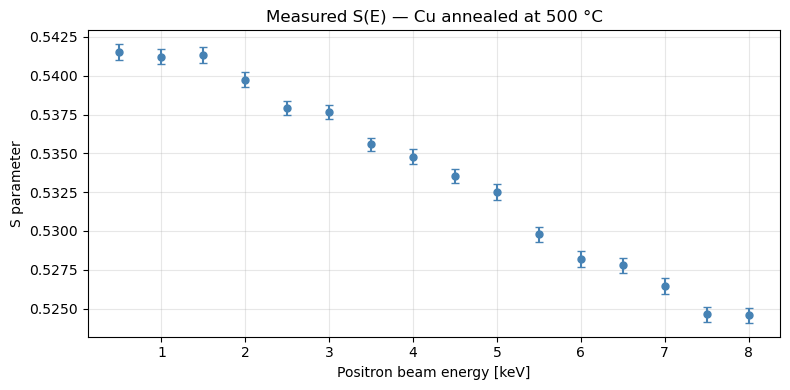

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(energies,
            nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=5)
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title('Measured S(E) — Cu annealed at 500 °C')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Sample model and implantation profiles

For a bulk Cu sample (annealed, effectively defect-free apart from the near-surface region) a **single-layer model** is appropriate: one semi-infinite Cu layer with diffusion length L₊ as the only free parameter.

The initial guess L₊ = 100 nm is a typical value for metals. The optimizer is not sensitive to this choice as long as it is in the physically plausible range.

The **Makhov profile** describes the positron stopping distribution. Cu material parameters are taken from the built-in table; the bulk density is set to 8.96 g/cm³.

> **Adapt** the layer width, initial diffusion length, and material density for your sample.

In [4]:
# ── Adapt to your sample ──────────────────────────────────────────────────────
L_init  = 100.0   # initial diffusion length guess [nm]
D       = 1.0     # diffusion coefficient [nm²/ps] — normalized; only L = sqrt(D/λ) matters
layer_width       = 10_000   # [nm] — thick enough that c(z) → 0 at the far end
absorption_length = 1.0      # surface absorption length [nm]
# ─────────────────────────────────────────────────────────────────────────────

initial_layer  = Layer(width=layer_width,
                       material=Material(diffusion=D, mobility=0,
                                         bulk_annihilation_rate=D / L_init**2))
initial_sample = Sample(layers=[initial_layer], absorption_length=absorption_length)

# Makhov parameters for Cu (row 9 in the built-in table); set bulk density
Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96   # g/cm³

print(f'Initial guess:   L₊ = {L_init} nm')
print(f'Sample length:   {initial_sample.sample_length()} nm')
print(f'Cu Makhov params:\n{Cu_params}')

Initial guess:   L₊ = 100.0 nm
Sample length:   10000.0 nm
Cu Makhov params:
Material       Cu
density      8.96
Z              29
m           1.729
n           1.667
A_half       2.58
Name: 9, dtype: object


In [5]:
# Depth vector for implantation profiles — spans the full sample length
depth = np.linspace(0, initial_sample.sample_length(), 20_000)  # [nm]

# One Makhov implantation profile per measured beam energy
positron_implantation_profiles = [
    multilayer_implantation_profile(
        positron_energy=e,
        depth_vector=depth,
        widths=[initial_layer.width],
        materials_parameters=[Cu_params],
        densities=[Cu_params['density']],
        implantation_profile_function=makhov_profile
    )
    for e in energies
]
print(f'Computed {len(positron_implantation_profiles)} implantation profiles')

Computed 16 implantation profiles


## 3. Diffusion-length optimization

`DiffusionLengthOptimization` performs nonlinear least-squares minimization of the weighted residuals between measured and modeled S(E). For each trial L₊ the transport equation is solved for every beam energy, annihilation fractions are computed per layer, and S per channel is estimated via linear least squares.

**`num_of_mesh_cells`** controls the spatial resolution of the transport solver. 10 000 cells is sufficient for a single-layer metal sample. Increase to 50 000–100 000 for multi-layer samples or when the diffusion length is much shorter than the layer width.

> **Note:** `optimize_diffusion_length()` typically takes 1–3 minutes for 16 energy points at 10 000 mesh cells.

In [6]:
vedbfit = DiffusionLengthOptimization(
    positron_implantation_profiles=positron_implantation_profiles,
    s_measurement=s_measurement,
    initial_guess=initial_sample,
    num_of_mesh_cells=10_000,   # increase for higher accuracy
)

In [7]:
# ── This cell may take 1–3 minutes ───────────────────────────────────────────
best_fit, cov = vedbfit.optimize_diffusion_length(bounds=(0, 1000))
# ─────────────────────────────────────────────────────────────────────────────

L_fit = best_fit[0]                 # best-fit diffusion length [nm]
L_err = np.sqrt(cov[0, 0])         # marginal 1σ uncertainty [nm]

print(f'Fitted diffusion length:  L₊ = {L_fit:.1f} ± {L_err:.1f} nm')

Fitted diffusion length:  L₊ = 130.7 ± 25.0 nm


## 4. Fit vs measurement

To draw a smooth fit curve, the transport equation is solved on a dense energy grid (0.5–8.5 keV) using the fitted sample. The S-parameter per annihilation channel (`s_per_channel`) is first estimated from the measurement energies, then applied to the dense grid.

In [8]:
# Build fitted sample and get S per annihilation channel
sample_fit    = vedbfit.make_sample(best_fit)
frac_matrix   = vedbfit.layers_transport_solver(sample_fit, positron_implantation_profiles)
s_per_channel = vedbfit.layer_s_value(frac_matrix)  # [S_surface, S_bulk]

print(f'S_surface = {s_per_channel[0]:.4f}')
print(f'S_bulk    = {s_per_channel[1]:.4f}')

S_surface = 0.5426
S_bulk    = 0.5051


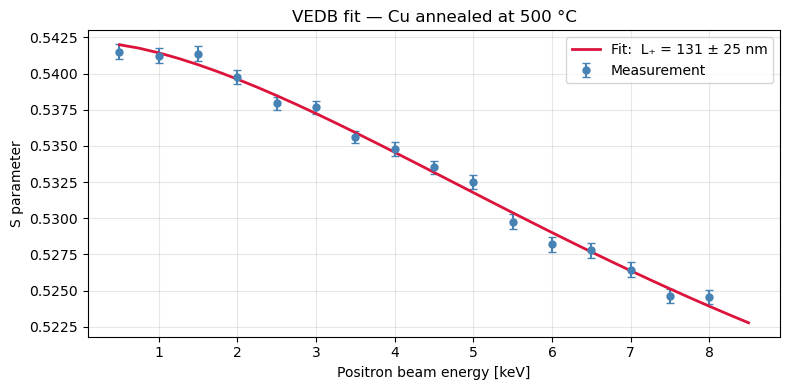

In [9]:
# Dense energy grid for smooth fit curve
plt_energies = np.arange(0.5, 8.6, 0.25)   # [keV]

profiles_dense = [
    multilayer_implantation_profile(
        positron_energy=e,
        depth_vector=depth,
        widths=[initial_layer.width],
        materials_parameters=[Cu_params],
        densities=[Cu_params['density']],
        implantation_profile_function=makhov_profile
    )
    for e in plt_energies
]

frac_matrix_dense = vedbfit.layers_transport_solver(sample_fit, profiles_dense)
s_fit_curve = frac_matrix_dense @ s_per_channel

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(energies,
            nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=5, label='Measurement')
ax.plot(plt_energies, s_fit_curve, '-', color='crimson', lw=2,
        label=f'Fit:  L₊ = {L_fit:.0f} ± {L_err:.0f} nm')
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title('VEDB fit — Cu annealed at 500 °C')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. S per annihilation channel

The linear least-squares step inside the optimizer estimates the S-parameter characteristic of each annihilation channel:

- **S_surface**: S seen by positrons annihilating at the sample surface (z = 0). Higher than the bulk value indicates a surface oxide or high defect density at the surface.
- **S_bulk**: S seen by positrons annihilating in the bulk Cu. Should match the bulk reference value for annealed Cu.

These values are estimated by least-squares and are not independent free parameters — they are derived from the data given the fitted L₊.

S per annihilation channel:
  S_surface = 0.5426
  S_layer_0 = 0.5051


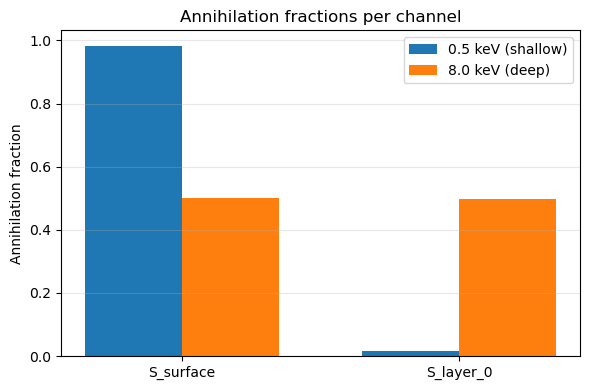

In [10]:
labels = ['S_surface'] + [f'S_layer_{i}' for i in range(vedbfit.n_layers)]
print('S per annihilation channel:')
for label, val in zip(labels, s_per_channel):
    print(f'  {label} = {val:.4f}')

# Visualise the annihilation fractions at the lowest and highest beam energies
fracs_low  = frac_matrix[0]    # lowest measured energy
fracs_high = frac_matrix[-1]   # highest measured energy

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, fracs_low,  width, label=f'{energies[0]:.1f} keV (shallow)')
ax.bar(x + width/2, fracs_high, width, label=f'{energies[-1]:.1f} keV (deep)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Annihilation fraction')
ax.set_title('Annihilation fractions per channel')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. χ² profile and confidence intervals

The Jacobian-based uncertainty from the optimizer is a local (symmetric) approximation valid near the minimum. The **χ² profile** provides the full picture: for each trial L₊ on a grid the weighted residuals are recomputed — with S per channel re-estimated at each point via linear least squares — and Δχ² = χ²(L) − χ²_min is plotted.

Confidence intervals follow from standard chi-squared statistics for one free parameter:

| Confidence level | Δχ² threshold |
|---|---|
| 68.3 % (1σ) | 1.00 |
| 95.0 % (2σ) | 3.84 |
| 99.0 % (3σ) | 6.63 |

The profile may be asymmetric: the upper bound on L₊ can be weakly constrained if the beam energy range does not extend to implantation depths much larger than L₊.

In [11]:
# ── χ² grid scan — typically takes 1–2 minutes ────────────────────────────────
L_grid = np.arange(20, 505, 5, dtype=float)   # trial diffusion lengths [nm]

chi2_grid = np.full(len(L_grid), np.nan)
for k, L in enumerate(L_grid):
    res = vedbfit.residuals(np.array([L]))
    if not np.any(np.abs(res) > 1e5):   # skip penalised (unphysical) points
        chi2_grid[k] = float(np.sum(res**2))
# ─────────────────────────────────────────────────────────────────────────────

delta_chi2 = chi2_grid - np.nanmin(chi2_grid)
print('χ² scan complete')
print(f'χ²_min at L = {L_grid[np.nanargmin(chi2_grid)]:.0f} nm')

χ² scan complete
χ²_min at L = 130 nm


In [12]:
def ci_bounds(L_grid, delta_chi2, threshold):
    """Return (lower, upper) CI bounds by linear interpolation of crossing points."""
    crossings = []
    for i in range(len(delta_chi2) - 1):
        a, b = delta_chi2[i], delta_chi2[i + 1]
        if np.isnan(a) or np.isnan(b):
            continue
        if (a - threshold) * (b - threshold) < 0:
            frac = (threshold - a) / (b - a)
            crossings.append(L_grid[i] + frac * (L_grid[i + 1] - L_grid[i]))
    return crossings

THRESH_68, THRESH_95, THRESH_99 = 1.00, 3.84, 6.63

bounds_68 = ci_bounds(L_grid, delta_chi2, THRESH_68)
bounds_95 = ci_bounds(L_grid, delta_chi2, THRESH_95)
bounds_99 = ci_bounds(L_grid, delta_chi2, THRESH_99)

print(f'Fitted L₊:  {L_fit:.1f} nm  (Jacobian: ±{L_err:.1f} nm)')
if len(bounds_68) == 2:
    print(f'68% CI:     [{bounds_68[0]:.0f}, {bounds_68[1]:.0f}] nm  '
          f'(+{bounds_68[1]-L_fit:.0f} / -{L_fit-bounds_68[0]:.0f} nm)')
if len(bounds_95) == 2:
    print(f'95% CI:     [{bounds_95[0]:.0f}, {bounds_95[1]:.0f}] nm')
if len(bounds_99) == 2:
    print(f'99% CI:     [{bounds_99[0]:.0f}, {bounds_99[1]:.0f}] nm')
if len(bounds_95) < 2:
    print('95% CI upper bound > scan range — extend L_grid if needed')

Fitted L₊:  130.7 nm  (Jacobian: ±25.0 nm)
68% CI:     [110, 160] nm  (+29 / -21 nm)
95% CI:     [95, 202] nm
99% CI:     [87, 240] nm


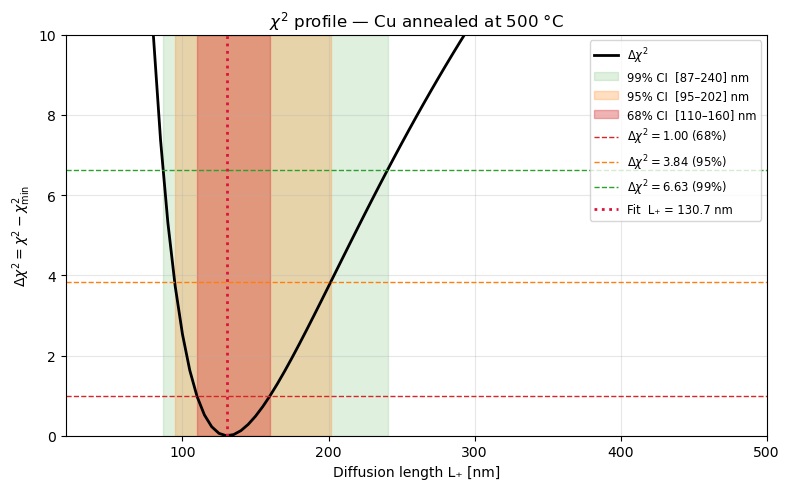

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(L_grid, delta_chi2, 'k-', lw=2, label=r'$\Delta\chi^2$')

if len(bounds_99) == 2:
    ax.axvspan(*bounds_99, color='tab:green',  alpha=0.15,
               label=f'99% CI  [{bounds_99[0]:.0f}–{bounds_99[1]:.0f}] nm')
if len(bounds_95) == 2:
    ax.axvspan(*bounds_95, color='tab:orange', alpha=0.25,
               label=f'95% CI  [{bounds_95[0]:.0f}–{bounds_95[1]:.0f}] nm')
if len(bounds_68) == 2:
    ax.axvspan(*bounds_68, color='tab:red',    alpha=0.35,
               label=f'68% CI  [{bounds_68[0]:.0f}–{bounds_68[1]:.0f}] nm')

ax.axhline(THRESH_68, color='tab:red',    ls='--', lw=1, label=r'$\Delta\chi^2 = 1.00$ (68%)')
ax.axhline(THRESH_95, color='tab:orange', ls='--', lw=1, label=r'$\Delta\chi^2 = 3.84$ (95%)')
ax.axhline(THRESH_99, color='tab:green',  ls='--', lw=1, label=r'$\Delta\chi^2 = 6.63$ (99%)')

ax.axvline(L_fit, color='crimson', ls=':', lw=2,
           label=f'Fit  L₊ = {L_fit:.1f} nm')

ax.set_xlabel('Diffusion length L₊ [nm]')
ax.set_ylabel(r'$\Delta\chi^2 = \chi^2 - \chi^2_{\min}$')
ax.set_title(r'$\chi^2$ profile — Cu annealed at 500 °C')
ax.set_ylim(0, 10)
ax.set_xlim(L_grid[0], L_grid[-1])
ax.legend(fontsize='small', loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()